# 🚀 SPEC-03 (Kaggle T4 GPU Edition - XLM-RoBERTa Dedicated Training & Evaluation)
## 📌 XLM-RoBERTa-large (550M) Multi-Head Classifier 5-Fold Stratified Cross-Validation

- **Target Model:** **XLM-RoBERTa-large** (`xlm-roberta-large`, 550M Multilingual Target)
- **Training Scheme:** 5-Fold Stratified Cross-Validation, 20 Epochs per fold
- **Key Features & Enhancements:**
  1. **Kaggle Environment Native Directories:** Pencarian otomatis dataset pada `/kaggle/input` (support `valid_labeled_comments.csv` maupun `train.csv` + `val.csv`).
  2. **Learning Curves Analysis:** Melacak dan memvisualisasikan kurva *Train/Val Loss* serta *Val Macro F1* per epoch.
  3. **4x4 Confusion Matrices per Aspek:** Analisis matriks konfusi komprehensif untuk 4 aspek (`Infrastruktur`, `Ekonomi`, `Kualitas`, `Purnajual`).
  4. **Single Best Model Disk Safeguard:** Hanya menyimpan **1 model terbaik (~2.2 GB)** dari seluruh fold untuk menghemat kuota disk Kaggle.
  5. **Real-Time Val F1 Progress:** Logging *Train Loss*, *Val Loss*, *Val F1 (Active)*, dan *Val Acc* secara otomatis per epoch.
  6. **Aspect-Customized Thresholding (${\theta}_{\text{aspect}}$):** `purnajual`: 0.35, `infra`: 0.40, `ekonomi`: 0.50, `kualitas`: 0.50.
  7. **Complete Evaluation Artifacts Package:** Menghasilkan file ZIP model, CSV/JSON metrik evaluasi, dan file gambar resolusi tinggi (`.png`) yang siap diunduh langsung dari Kaggle Output.


## 1. Setup Dependencies, Kaggle T4 GPU Detection & Imports


In [1]:
# Install required packages for Kaggle T4 GPU
!pip install -q -U transformers accelerate scikit-learn seaborn matplotlib tqdm wordcloud openpyxl

import os
import gc
import json
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup, AutoModel, AutoTokenizer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Style plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Check CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Device Utama: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"💾 Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set Random Seed for Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

LABEL2ID = {'None': 0, 'none': 0, 'positif': 1, 'netral': 2, 'negatif': 3}
ID2LABEL = {0: 'None', 1: 'positif', 2: 'netral', 3: 'negatif'}
ASPECTS = ['infra', 'ekonomi', 'kualitas', 'purnajual']
CLASS_NAMES = ['None', 'Positif', 'Netral', 'Negatif']

# Aspect-customized decision thresholds
ASPECT_THRESHOLDS = {
    "infra": 0.40,
    "ekonomi": 0.50,
    "kualitas": 0.50,
    "purnajual": 0.35,
}


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 102.4 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 112.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 120.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.6 MB/s eta 0:00:0000:01

## 2. Load Full Gold Standard Dataset (Kaggle Input Auto-Detection)


In [2]:
# Search for dataset file (valid_labeled_comments.csv or train.csv + val.csv)
data_dir = None
possible_paths = [
    Path("/kaggle/input/indonesian-ev-absa-dataset"),
    Path("/kaggle/input"),
    Path("data/interim"),
    Path("data/processed"),
    Path("../data/interim"),
    Path("../data/processed")
]

full_df = None
for p in possible_paths:
    if p.exists():
        if (p / "valid_labeled_comments.csv").exists():
            full_df = pd.read_csv(p / "valid_labeled_comments.csv", encoding="utf-8-sig")
            data_dir = p
            break
        elif (p / "train.csv").exists() and (p / "val.csv").exists():
            df_tr = pd.read_csv(p / "train.csv", encoding="utf-8-sig")
            df_va = pd.read_csv(p / "val.csv", encoding="utf-8-sig")
            full_df = pd.concat([df_tr, df_va], ignore_index=True)
            data_dir = p
            break
        # Search subdirectories inside /kaggle/input
        matches = list(p.glob("**/valid_labeled_comments.csv"))
        if matches:
            full_df = pd.read_csv(matches[0], encoding="utf-8-sig")
            data_dir = matches[0].parent
            break
        matches_tr = list(p.glob("**/train.csv"))
        if matches_tr:
            data_dir = matches_tr[0].parent
            df_tr = pd.read_csv(data_dir / "train.csv", encoding="utf-8-sig")
            df_va = pd.read_csv(data_dir / "val.csv", encoding="utf-8-sig")
            full_df = pd.concat([df_tr, df_va], ignore_index=True)
            break

if full_df is None:
    raise FileNotFoundError("❌ Tidak dapat menemukan berkas dataset terlabel! Harap upload dataset ke Kaggle.")

print(f"✅ Total Pure Human Gold Standard Dataset: {len(full_df)} baris (dari {data_dir.resolve()})")

# Create Stratification Key for Multi-Aspect Stratified K-Fold
aspect_cols = [f"{a}_sentiment" for a in ASPECTS]
full_df['strat_key'] = (
    full_df[aspect_cols[0]].fillna('none').astype(str) + '_' +
    full_df[aspect_cols[1]].fillna('none').astype(str) + '_' +
    full_df[aspect_cols[2]].fillna('none').astype(str) + '_' +
    full_df[aspect_cols[3]].fillna('none').astype(str)
)

counts = full_df['strat_key'].value_counts()
rare_keys = set(counts[counts < 5].index)
full_df['strat_label'] = full_df['strat_key'].apply(lambda x: 'rare_comb' if x in rare_keys else x)

display(full_df.head(3))


✅ Total Pure Human Gold Standard Dataset: 1377 baris (dari /kaggle/input/datasets/wicaksonohanifs/indonesian-ev-absa-dataset)


,comment_id,video_id,user_id_hash,text_original,like_count,published_at,updated_at,extracted_at,text_cleaned,infra_sentiment,...,kualitas_sentiment,purnajual_sentiment,label_source,human_infra,human_ekonomi,human_kualitas,human_purnajual,has_human_audit,strat_key,strat_label
0,UgzGTfTq3lM9nFtp3I94AaABAg,l8fPSUqdmOM,3222bd9ba1329cb2ec1c581ad2de2dd8951214ed996a64...,Wuling modelnya Tua kayak mobil orang tua...s...,0,2025-04-02T13:16:08Z,2025-04-02T13:16:24Z,2026-09-27T14:02:16.602859+00:00,wuling modelnya tua kayak mobil orang tua..say...,NaN,...,negatif,NaN,Human-Audit-GoldStandard,NaN,NaN,negatif,NaN,True,none_none_negatif_none,none_none_negatif_none
1,UgxxM0lMAOZyG2gGHs94AaABAg,9GTZD3la5qI,167b2e1b352ae85f32787a6b48b95a5ac7b5cb39a2afaa...,LFP baterai sih bisa 3000-6000x cycle... kalo ...,13,2024-01-31T01:25:49Z,2024-01-31T01:25:49Z,2026-09-27T14:02:22.040959+00:00,lfp baterai sih bisa 300-600x cycle.. kalo x40...,NaN,...,positif,NaN,Human-Audit-GoldStandard,NaN,NaN,positif,NaN,True,none_none_positif_none,none_none_positif_none
2,UgzEMwL3tCPGrlfuZot4AaABAg,AOjceFDyYeM,01949cfce25b7d34cfa59f2a8444c403dab13e648fd850...,"6:20 , waduh kategori rusak karena kasar sama...",1,2025-12-03T16:24:49Z,2025-12-03T16:24:49Z,2026-09-27T14:02:20.222873+00:00,"6:20 , waduh kategori rusak karena kasar sama ...",NaN,...,NaN,NaN,Human-Audit-GoldStandard,NaN,negatif,NaN,NaN,True,none_negatif_none_none,none_negatif_none_none


## 3. Loss Function (Focal Loss), Class Weights & ABSADataset


In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=-1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = torch.clamp(pt, min=1e-8, max=1.0)
        
        focal_weight = (1.0 - pt) ** self.gamma
        if self.alpha is not None:
            alpha_weight = self.alpha.to(inputs.device)[targets]
            focal_weight = focal_weight * alpha_weight

        loss = -focal_weight * torch.log(pt)
        return loss.mean()

def compute_aspect_class_weights(df, aspects=ASPECTS, smooth_factor=0.5):
    weights_dict = {}
    classes = np.array([0, 1, 2, 3])
    for aspect in aspects:
        col = f"{aspect}_sentiment"
        raw_vals = df[col].fillna("none").astype(str).str.lower().map(LABEL2ID).fillna(0).astype(int).values
        raw_weights = compute_class_weight(class_weight="balanced", classes=classes, y=raw_vals)
        smoothed = np.power(raw_weights, smooth_factor)
        smoothed = smoothed / np.mean(smoothed)
        weights_dict[aspect] = torch.tensor(smoothed, dtype=torch.float32).to(device)
    return weights_dict

class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, aspects=ASPECTS):
        if "text_cleaned" in df.columns:
            text_col = "text_cleaned"
        elif "text_original" in df.columns:
            text_col = "text_original"
        elif "comment_text" in df.columns:
            text_col = "comment_text"
        else:
            raise KeyError(f"❌ Tidak dapat menemukan kolom teks di DataFrame.")

        self.texts = df[text_col].fillna("").astype(str).tolist()
        self.labels = {}
        for aspect in aspects:
            col = f"{aspect}_sentiment"
            raw = df[col].fillna("none").astype(str).str.lower().map(LABEL2ID).fillna(0).astype(int).values
            self.labels[aspect] = torch.tensor(raw, dtype=torch.long)
        
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.aspects = aspects

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )
        
        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": {aspect: self.labels[aspect][idx] for aspect in self.aspects}
        }
        return item


## 4. XLM-RoBERTa-large Multi-Head Classifier Architecture (550M Target Model)


In [4]:
class XLMRoBERTaMultiHeadClassifier(nn.Module):
    def __init__(self, model_name="xlm-roberta-large", num_classes=4, dropout_prob=0.1, aspects=ASPECTS, focal_gamma=1.5):
        super().__init__()
        self.aspects = aspects
        self.focal_gamma = focal_gamma
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size  # 1024 for large

        # Expanded 2-Layer GELU MLP Head with LayerNorm (2048 -> 512 -> 4)
        self.heads = nn.ModuleDict({
            aspect: nn.Sequential(
                nn.Linear(hidden_size * 2, 512),
                nn.LayerNorm(512),
                nn.GELU(),
                nn.Dropout(dropout_prob),
                nn.Linear(512, num_classes)
            ) for aspect in aspects
        })

    def forward(self, input_ids, attention_mask, labels=None, class_weights=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        cls_token = last_hidden[:, 0, :]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask

        pooled_features = torch.cat([cls_token, mean_pooled], dim=-1)

        logits = {}
        total_loss = 0.0

        for aspect in self.aspects:
            aspect_logits = self.heads[aspect](pooled_features)
            logits[aspect] = aspect_logits

            if labels is not None:
                target = labels[aspect].to(aspect_logits.device)
                alpha = class_weights[aspect] if class_weights and aspect in class_weights else None
                criterion = FocalLoss(alpha=alpha, gamma=self.focal_gamma)
                total_loss += criterion(aspect_logits, target)

        output_dict = {"logits": logits}
        if labels is not None:
            output_dict["loss"] = total_loss
        return output_dict


## 5. Evaluation & Plotting Helpers (Learning Curves & Confusion Matrices)


In [5]:
def predict_with_threshold(logits, none_threshold=ASPECT_THRESHOLDS, aspect=None):
    if isinstance(none_threshold, dict) and aspect in none_threshold:
        thresh = none_threshold[aspect]
    elif isinstance(none_threshold, (int, float)):
        thresh = float(none_threshold)
    else:
        thresh = 0.50

    if isinstance(logits, torch.Tensor):
        probs = F.softmax(logits, dim=-1).detach().cpu().numpy()
    else:
        exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
        probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

    preds = []
    for i in range(probs.shape[0]):
        p_none = probs[i, 0]
        if p_none > thresh:
            preds.append(0)
        else:
            active_probs = probs[i, 1:]
            best_active_idx = int(np.argmax(active_probs)) + 1
            preds.append(best_active_idx)

    return np.array(preds)

def evaluate_predictions(y_true_dict, y_pred_dict, aspects=ASPECTS):
    aspect_metrics = {}
    cm_dict = {}
    macro_f1s_all, macro_f1s_active, accuracies = [], [], []

    for aspect in aspects:
        y_true = np.array(y_true_dict[aspect])
        y_pred = np.array(y_pred_dict[aspect])

        acc = accuracy_score(y_true, y_pred)
        f1_m_all = f1_score(y_true, y_pred, average="macro", zero_division=0)
        f1_m_active = f1_score(y_true, y_pred, labels=[1, 2, 3], average="macro", zero_division=0)

        prec_m = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec_m = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

        aspect_metrics[aspect] = {
            "accuracy": acc,
            "f1_macro_all": f1_m_all,
            "f1_macro_active": f1_m_active,
            "precision_macro": prec_m,
            "recall_macro": rec_m,
            "f1_weighted": f1_w,
        }
        cm_dict[aspect] = cm
        accuracies.append(acc)
        macro_f1s_all.append(f1_m_all)
        macro_f1s_active.append(f1_m_active)

    n_samples = len(y_true_dict[aspects[0]])
    exact_matches = sum(
        all(y_true_dict[asp][i] == y_pred_dict[asp][i] for asp in aspects)
        for i in range(n_samples)
    )
    exact_match_ratio = exact_matches / n_samples if n_samples > 0 else 0.0

    return {
        "per_aspect": aspect_metrics,
        "overall": {
            "mean_accuracy": float(np.mean(accuracies)),
            "mean_macro_f1_all": float(np.mean(macro_f1s_all)),
            "mean_macro_f1_active": float(np.mean(macro_f1s_active)),
            "exact_match_ratio": float(exact_match_ratio),
        },
        "confusion_matrices": cm_dict,
    }

def plot_learning_curves(history_df, model_name="XLM-RoBERTa-large", save_path="xlmroberta_learning_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"📈 Learning Curves (5-Fold Mean) — {model_name}", fontsize=15, fontweight="bold", y=0.98)

    epochs = history_df["epoch"]

    # Subplot 1: Train Loss vs Val Loss
    axes[0].plot(epochs, history_df["mean_train_loss"], label="Train Loss", color="#e74c3c", linewidth=2.5, marker="o")
    axes[0].plot(epochs, history_df["mean_val_loss"], label="Val Loss", color="#3498db", linewidth=2.5, marker="s", linestyle="--")
    axes[0].set_title("Loss Curve per Epoch", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].legend(frameon=True)
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # Subplot 2: Val Macro F1 Score
    axes[1].plot(epochs, history_df["mean_val_f1_active"], label="Val Macro F1 (Active Sentiments)", color="#2ecc71", linewidth=2.5, marker="^")
    axes[1].plot(epochs, history_df["mean_val_f1_all"], label="Val Macro F1 (All Classes)", color="#f39c12", linewidth=2.5, marker="d", linestyle="--")
    axes[1].set_title("Validation Macro F1-Score per Epoch", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("Macro F1-Score", fontsize=11)
    axes[1].legend(frameon=True)
    axes[1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"🖼️ Learning Curves saved to: {save_path}")
    return save_path

def plot_confusion_matrices(cm_dict, model_name="XLM-RoBERTa-large", save_path="xlmroberta_confusion_matrices.png", aspects=ASPECTS):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Confusion Matrices 4x4 — {model_name}", fontsize=16, fontweight="bold", y=0.98)

    for idx, aspect in enumerate(aspects):
        ax = axes[idx // 2, idx % 2]
        cm = cm_dict[aspect]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax.set_title(f"Aspek: {aspect.capitalize()}", fontsize=14, fontweight="semibold")
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label", fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"🖼️ Confusion Matrices saved to: {save_path}")
    return save_path


## 6. 5-Fold Stratified Cross-Validation Training Loop (Single Best Model Disk Safeguard)


In [6]:
def train_5fold_cv_update(
    model_class=XLMRoBERTaMultiHeadClassifier,
    model_name="xlm-roberta-large",
    tokenizer=None,
    full_df=None,
    epochs=20,
    lr=1.5e-5,
    batch_size=8,
    grad_accum=2,
    save_prefix="xlmroberta_absa"
):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_metrics = []
    epoch_histories = []  # Track epoch loss & F1 across folds
    
    save_dir = Path(f"models/{save_prefix}")
    save_dir.mkdir(parents=True, exist_ok=True)

    best_overall_val_f1 = 0.0
    best_model_path = save_dir / "pytorch_model.bin"

    print(f"\n🚀 STARTING 5-FOLD CROSS-VALIDATION: {model_name} ({epochs} Epochs per fold)")
    print(f"💾 SINGLE BEST MODEL DISK SAFEGUARD: Hanya menyimpan 1 model terbaik ({best_model_path.resolve()})")

    for fold, (train_idx, val_idx) in enumerate(skf.split(full_df, full_df['strat_label']), 1):
        print(f"\n========================================================")
        print(f"🔄 FOLD {fold}/5 — {model_name}")
        print(f"========================================================")

        train_fold_df = full_df.iloc[train_idx].reset_index(drop=True)
        val_fold_df = full_df.iloc[val_idx].reset_index(drop=True)

        class_weights = compute_aspect_class_weights(train_fold_df)

        train_dataset = ABSADataset(train_fold_df, tokenizer, max_len=128)
        val_dataset = ABSADataset(val_fold_df, tokenizer, max_len=128)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = model_class(model_name).to(device)

        total_steps = (len(train_loader) // grad_accum) * epochs
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=max(1, total_steps)
        )

        best_fold_f1_active = 0.0
        best_fold_eval = None
        fold_epoch_log = []

        for epoch in range(1, epochs + 1):
            model.train()
            total_train_loss = 0.0
            optimizer.zero_grad()

            for step, batch in enumerate(train_loader):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = {k: v.to(device) for k, v in batch["labels"].items()}

                output = model(input_ids, attention_mask, labels=labels, class_weights=class_weights)
                loss = output["loss"] / grad_accum
                loss.backward()

                if (step + 1) % grad_accum == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

                total_train_loss += loss.item() * grad_accum

            avg_train_loss = total_train_loss / len(train_loader)

            # Evaluate Val Loss & Val F1 for EVERY epoch
            model.eval()
            total_val_loss = 0.0
            y_true_epoch = {asp: [] for asp in ASPECTS}
            y_pred_epoch = {asp: [] for asp in ASPECTS}

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = {k: v.to(device) for k, v in batch["labels"].items()}

                    output = model(input_ids, attention_mask, labels=labels, class_weights=class_weights)
                    if "loss" in output:
                        total_val_loss += output["loss"].item()

                    logits = output["logits"]
                    for asp in ASPECTS:
                        preds = predict_with_threshold(logits[asp], aspect=asp)
                        y_pred_epoch[asp].extend(preds)
                        y_true_epoch[asp].extend(labels[asp].cpu().numpy())

            avg_val_loss = total_val_loss / len(val_loader) if len(val_loader) > 0 else 0.0
            epoch_eval = evaluate_predictions(y_true_epoch, y_pred_epoch)
            val_f1_act = epoch_eval["overall"]["mean_macro_f1_active"]
            val_f1_all = epoch_eval["overall"]["mean_macro_f1_all"]
            val_acc = epoch_eval["overall"]["mean_accuracy"]

            fold_epoch_log.append({
                "epoch": epoch,
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "val_f1_active": val_f1_act,
                "val_f1_all": val_f1_all,
                "val_acc": val_acc
            })

            # Real-Time Log Display per Epoch
            print(f"  Epoch {epoch:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1 (Active): {val_f1_act:.4f} | Val F1 (All): {val_f1_all:.4f} | Val Acc: {val_acc:.4f}")

            if val_f1_act > best_fold_f1_active:
                best_fold_f1_active = val_f1_act
                best_fold_eval = epoch_eval

            # Check if this is the overall single best model across ALL 5 folds
            if val_f1_act > best_overall_val_f1:
                best_overall_val_f1 = val_f1_act
                torch.save(model.state_dict(), best_model_path)
                print(f"  🌟 NEW BEST OVERALL MODEL SAVED! (Val F1 Active: {val_f1_act:.4f})")

        print(f"⭐ Fold {fold} Best Val F1 (Active): {best_fold_f1_active:.4f}")
        fold_metrics.append(best_fold_eval)
        epoch_histories.append(pd.DataFrame(fold_epoch_log))

        # Explicit memory release per fold
        del model, optimizer, scheduler
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    tokenizer.save_pretrained(save_dir)

    # Compute Average Epoch History across all 5 folds for Learning Curves
    mean_history = pd.DataFrame({
        "epoch": range(1, epochs + 1),
        "mean_train_loss": np.mean([h["train_loss"].values for h in epoch_histories], axis=0),
        "mean_val_loss": np.mean([h["val_loss"].values for h in epoch_histories], axis=0),
        "mean_val_f1_active": np.mean([h["val_f1_active"].values for h in epoch_histories], axis=0),
        "mean_val_f1_all": np.mean([h["val_f1_all"].values for h in epoch_histories], axis=0),
        "mean_val_acc": np.mean([h["val_acc"].values for h in epoch_histories], axis=0),
    })

    print(f"\n🏆 SUCCESS: 5-Fold Cross Validation Completed for {model_name}!")
    print(f"💾 Single Best Model Saved at: {best_model_path.resolve()} (Best F1 Active: {best_overall_val_f1:.4f})")
    return fold_metrics, mean_history


## 7. Eksekusi Pelatihan 5-Fold CV — XLM-RoBERTa-large (550M Target Model)


In [7]:
xlm_model_name = "xlm-roberta-large"
print(f"📦 Mengunduh & Memuat Tokenizer: {xlm_model_name}...")
xlm_tokenizer = AutoTokenizer.from_pretrained(xlm_model_name)

xlm_fold_metrics, xlm_mean_history = train_5fold_cv_update(
    model_class=XLMRoBERTaMultiHeadClassifier,
    model_name=xlm_model_name,
    tokenizer=xlm_tokenizer,
    full_df=full_df,
    epochs=20,
    lr=1.5e-5,
    batch_size=8,
    grad_accum=2,
    save_prefix="xlmroberta_absa"
)

xlm_f1_active_folds = [m["overall"]["mean_macro_f1_active"] for m in xlm_fold_metrics]
xlm_f1_all_folds = [m["overall"]["mean_macro_f1_all"] for m in xlm_fold_metrics]
xlm_acc_folds = [m["overall"]["mean_accuracy"] for m in xlm_fold_metrics]

print("\n📊 HASIL EVALUASI 5-FOLD CV — XLM-ROBERTA-LARGE (550M):")
print(f"  • Mean Macro F1 (Active Sentiments): {np.mean(xlm_f1_active_folds):.4f} ± {np.std(xlm_f1_active_folds):.4f}")
print(f"  • Mean Macro F1 (All Classes)      : {np.mean(xlm_f1_all_folds):.4f} ± {np.std(xlm_f1_all_folds):.4f}")
print(f"  • Mean Accuracy                  : {np.mean(xlm_acc_folds):.4f} ± {np.std(xlm_acc_folds):.4f}")


📦 Mengunduh & Memuat Tokenizer: xlm-roberta-large...


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/20 | Train Loss: 2.1503 | Val Loss: 1.9300 | Val F1 (Active): 0.0646 | Val F1 (All): 0.1628 | Val Acc: 0.5100
  Epoch  2/20 | Train Loss: 1.9069 | Val Loss: 1.6168 | Val F1 (Active): 0.1837 | Val F1 (All): 0.3287 | Val Acc: 0.6445
  Epoch  3/20 | Train Loss: 1.3601 | Val Loss: 1.3702 | Val F1 (Active): 0.3791 | Val F1 (All): 0.4762 | Val Acc: 0.7009
  Epoch  4/20 | Train Loss: 0.9767 | Val Loss: 1.1948 | Val F1 (Active): 0.4417 | Val F1 (All): 0.5491 | Val Acc: 0.7664
  Epoch  5/20 | Train Loss: 0.7197 | Val Loss: 1.1865 | Val F1 (Active): 0.4408 | Val F1 (All): 0.5512 | Val Acc: 0.7745
  Epoch  6/20 | Train Loss: 0.5842 | Val Loss: 1.1009 | Val F1 (Active): 0.4833 | Val F1 (All): 0.5867 | Val Acc: 0.7973
  Epoch  9/20 | Train Loss: 0.2060 | Val Loss: 1.3524 | Val F1 (Active): 0.4859 | Val F1 (All): 0.5884 | Val Acc: 0.8000
  Epoch 12/20 | Train Loss: 0.0736 | Val Loss: 1.4289 | Val F1 (Active): 0.5269 | Val F1 (All): 0.6221 | Val Acc: 0.8227
  Epoch 15/20 | Train Loss: 0.03

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/20 | Train Loss: 2.1969 | Val Loss: 1.9230 | Val F1 (Active): 0.0627 | Val F1 (All): 0.1618 | Val Acc: 0.5082
  Epoch  2/20 | Train Loss: 1.8932 | Val Loss: 1.5345 | Val F1 (Active): 0.2401 | Val F1 (All): 0.3742 | Val Acc: 0.6991
  Epoch  3/20 | Train Loss: 1.3644 | Val Loss: 1.0652 | Val F1 (Active): 0.4673 | Val F1 (All): 0.5610 | Val Acc: 0.7527
  Epoch  4/20 | Train Loss: 0.9487 | Val Loss: 0.9505 | Val F1 (Active): 0.5181 | Val F1 (All): 0.6101 | Val Acc: 0.7991
  Epoch  5/20 | Train Loss: 0.6590 | Val Loss: 1.0953 | Val F1 (Active): 0.4861 | Val F1 (All): 0.5903 | Val Acc: 0.8000
  Epoch  6/20 | Train Loss: 0.6591 | Val Loss: 1.0226 | Val F1 (Active): 0.5308 | Val F1 (All): 0.6261 | Val Acc: 0.8255
  Epoch  7/20 | Train Loss: 0.4344 | Val Loss: 1.0586 | Val F1 (Active): 0.5381 | Val F1 (All): 0.6319 | Val Acc: 0.8282
  Epoch  8/20 | Train Loss: 0.2847 | Val Loss: 1.0907 | Val F1 (Active): 0.5183 | Val F1 (All): 0.6193 | Val Acc: 0.8318
  Epoch  9/20 | Train Loss: 0.20

## 8. Render & Save Learning Curves and Confusion Matrices Plots


/tmp/ipykernel_58/2073806699.py:101: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/tmp/ipykernel_58/2073806699.py:102: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


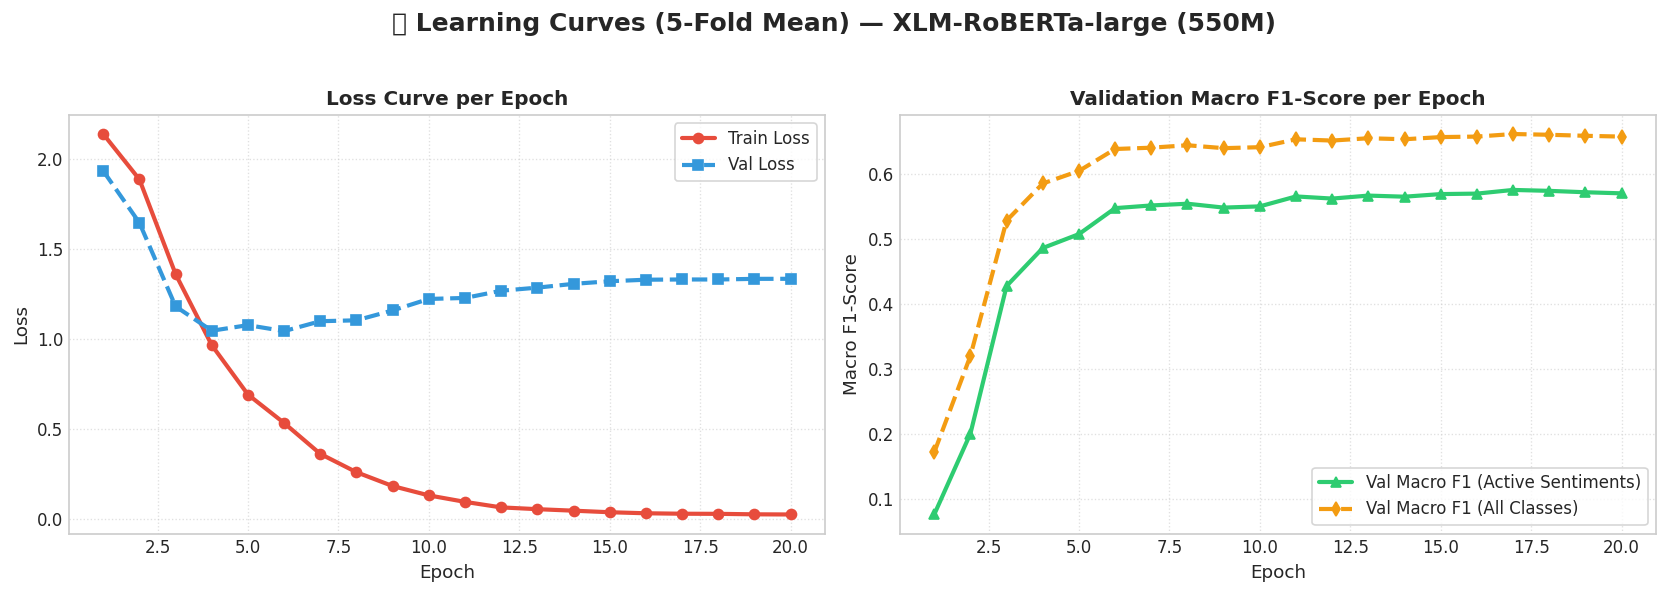

🖼️ Learning Curves saved to: xlmroberta_learning_curves.png


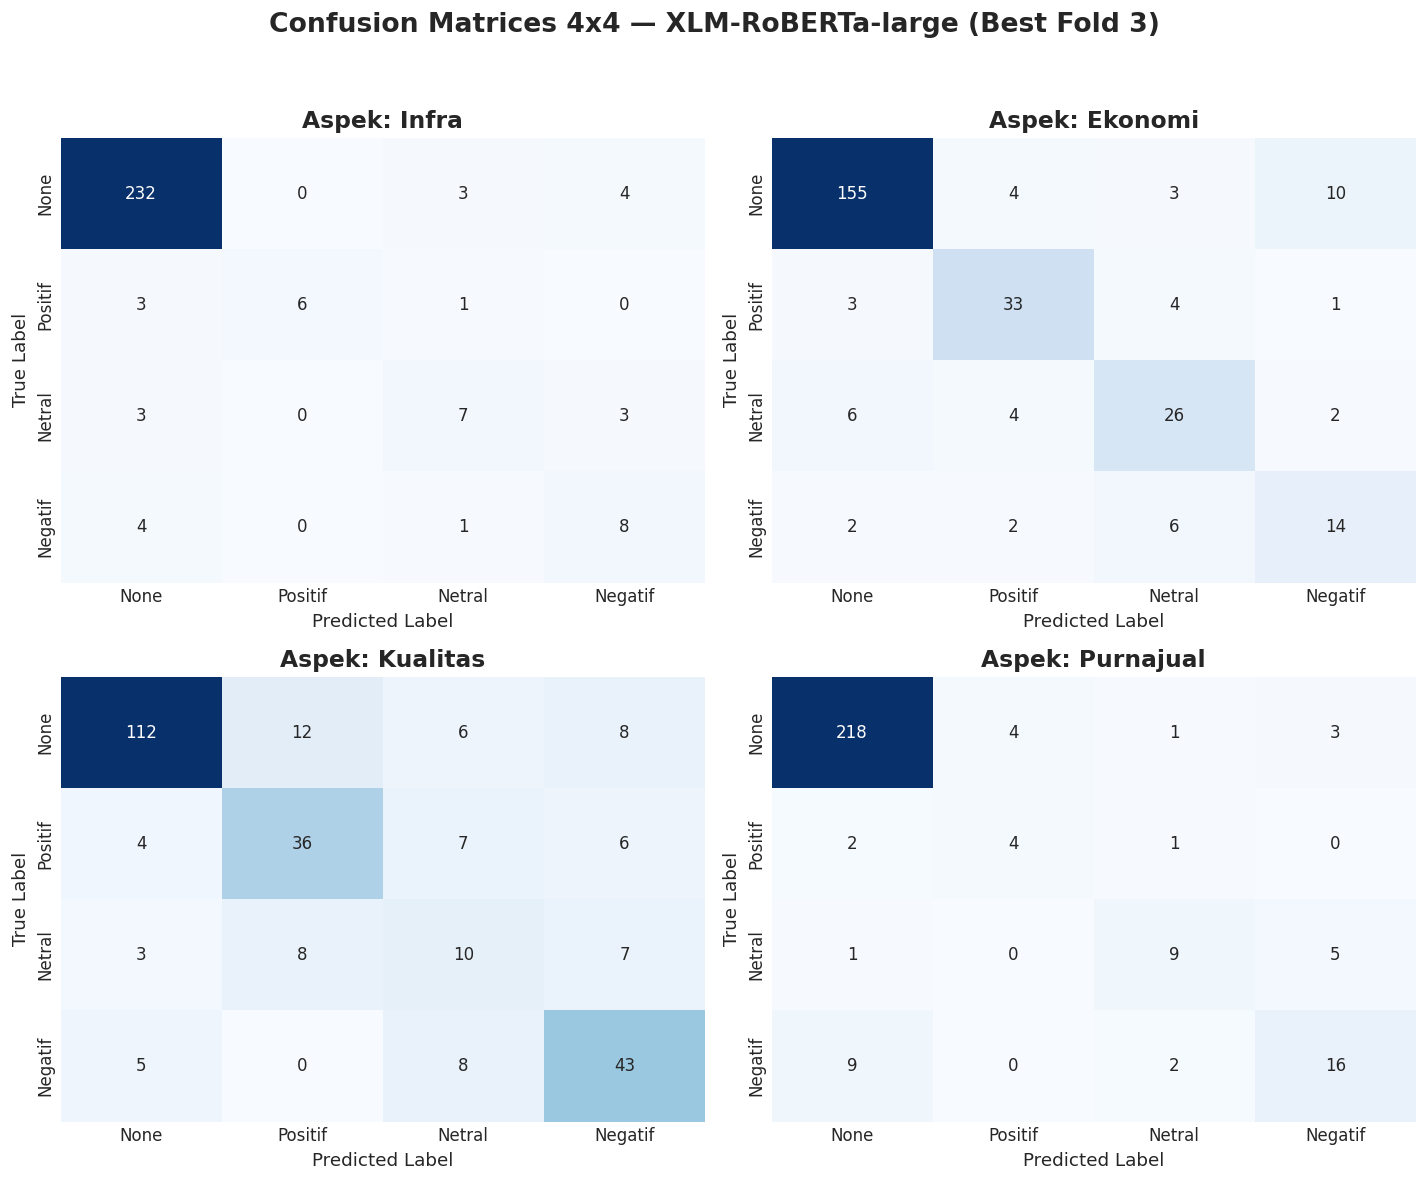

🖼️ Confusion Matrices saved to: xlmroberta_confusion_matrices.png
✅ Plot Learning Curves & Confusion Matrices berhasil di-render dan disimpan!


In [8]:
# 1. Render & Simpan Learning Curves Plot
plot_learning_curves(xlm_mean_history, model_name="XLM-RoBERTa-large (550M)", save_path="xlmroberta_learning_curves.png")

# 2. Render & Simpan Confusion Matrices Plot (Best Fold)
best_fold_idx = int(np.argmax(xlm_f1_active_folds))
best_cm_dict = xlm_fold_metrics[best_fold_idx]["confusion_matrices"]
plot_confusion_matrices(best_cm_dict, model_name=f"XLM-RoBERTa-large (Best Fold {best_fold_idx+1})", save_path="xlmroberta_confusion_matrices.png")

print("✅ Plot Learning Curves & Confusion Matrices berhasil di-render dan disimpan!")


## 9. Export Summary Metrics CSV/JSON & Package Model Zip File


In [9]:
# 1. Save Summary CSV
summary_df = pd.DataFrame([{
    "Model": "XLM-RoBERTa-large Classifier (550M)",
    "Mean Macro F1 (Active)": f"{np.mean(xlm_f1_active_folds):.4f} ± {np.std(xlm_f1_active_folds):.4f}",
    "Mean Macro F1 (All)": f"{np.mean(xlm_f1_all_folds):.4f} ± {np.std(xlm_f1_all_folds):.4f}",
    "Mean Accuracy": f"{np.mean(xlm_acc_folds):.4f} ± {np.std(xlm_acc_folds):.4f}",
}])

display(summary_df)
summary_df.to_csv("xlmroberta_metrics_5fold.csv", index=False)

# 2. Save JSON Details
summary_json = {
    "xlmroberta_5fold": {
        "mean_f1_active": float(np.mean(xlm_f1_active_folds)),
        "std_f1_active": float(np.std(xlm_f1_active_folds)),
        "mean_f1_all": float(np.mean(xlm_f1_all_folds)),
        "std_f1_all": float(np.std(xlm_f1_all_folds)),
        "mean_accuracy": float(np.mean(xlm_acc_folds)),
        "std_accuracy": float(np.std(xlm_acc_folds)),
        "folds": xlm_fold_metrics
    }
}
with open("xlmroberta_metrics_5fold.json", "w", encoding="utf-8") as f:
    json.dump(summary_json, f, indent=2, default=str)

# 3. Zip Model Checkpoint for Easy Download
def zip_dir(source_dir, zip_filename):
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as ziph:
        for root, dirs, files in os.walk(source_dir):
            for file in files:
                filepath = os.path.join(root, file)
                arcname = os.path.relpath(filepath, source_dir)
                ziph.write(filepath, arcname)
    print(f"📦 Zipped '{source_dir}' -> '{zip_filename}' ({os.path.getsize(zip_filename) / 1e6:.2f} MB)")

zip_dir("models/xlmroberta_absa", "xlmroberta_absa_model.zip")

print("\n🎉 SELESAI! Berkas evaluasi & model berikut siap diunduh dari Kaggle Output:")
print("  1. xlmroberta_absa_model.zip (~2.1 GB - Single Best Model Checkpoint)")
print("  2. xlmroberta_learning_curves.png (Grafik Train/Val Loss & Macro F1 Curve)")
print("  3. xlmroberta_confusion_matrices.png (Grafik 4x4 Confusion Matrix per Aspek)")
print("  4. xlmroberta_metrics_5fold.csv & xlmroberta_metrics_5fold.json (Laporan Evaluasi Lengkap)")


,Model,Mean Macro F1 (Active),Mean Macro F1 (All),Mean Accuracy
0,XLM-RoBERTa-large Classifier (550M),0.5826 ± 0.0338,0.6666 ± 0.0264,0.8382 ± 0.0080


📦 Zipped 'models/xlmroberta_absa' -> 'xlmroberta_absa_model.zip' (1769.17 MB)

🎉 SELESAI! Berkas evaluasi & model berikut siap diunduh dari Kaggle Output:
  1. xlmroberta_absa_model.zip (~2.1 GB - Single Best Model Checkpoint)
  2. xlmroberta_learning_curves.png (Grafik Train/Val Loss & Macro F1 Curve)
  3. xlmroberta_confusion_matrices.png (Grafik 4x4 Confusion Matrix per Aspek)
  4. xlmroberta_metrics_5fold.csv & xlmroberta_metrics_5fold.json (Laporan Evaluasi Lengkap)
